In [9]:
import xarray as xr
import numpy as np

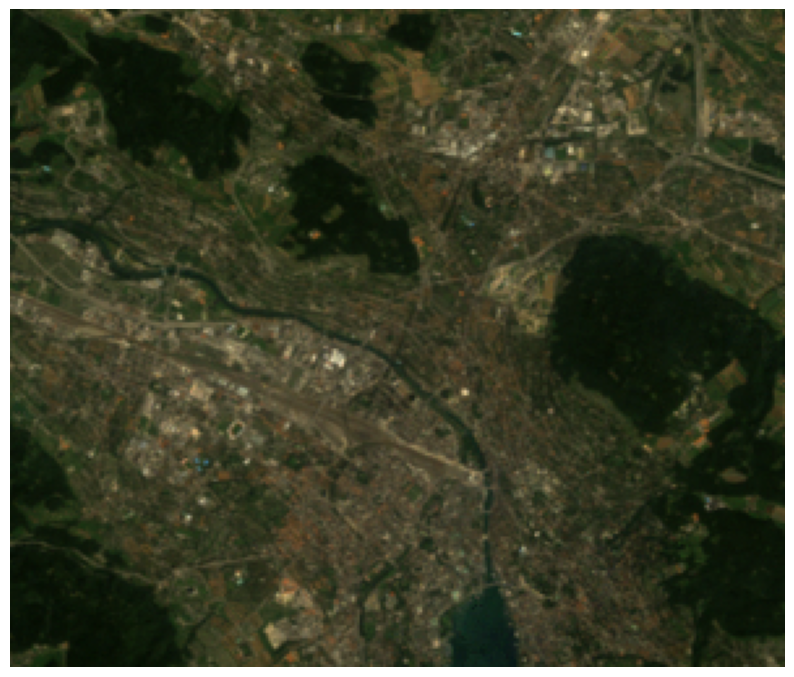

In [14]:
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt

ds = rxr.open_rasterio("../data/raw/Landsat/LandsatComposite_Zurich_1985.tif")

red   = ds.sel(band=3).values
green = ds.sel(band=2).values
blue  = ds.sel(band=1).values

rgb = np.stack([red, green, blue], axis=-1)

# Mask nodata (0)
rgb = np.where(rgb == 0, np.nan, rgb)

# Normalize
rgb_min = np.nanmin(rgb)
rgb_max = np.nanmax(rgb)
rgb_norm = (rgb - rgb_min) / (rgb_max - rgb_min)

plt.figure(figsize=(10,10))
plt.imshow(rgb_norm)
plt.axis("off")
plt.show()

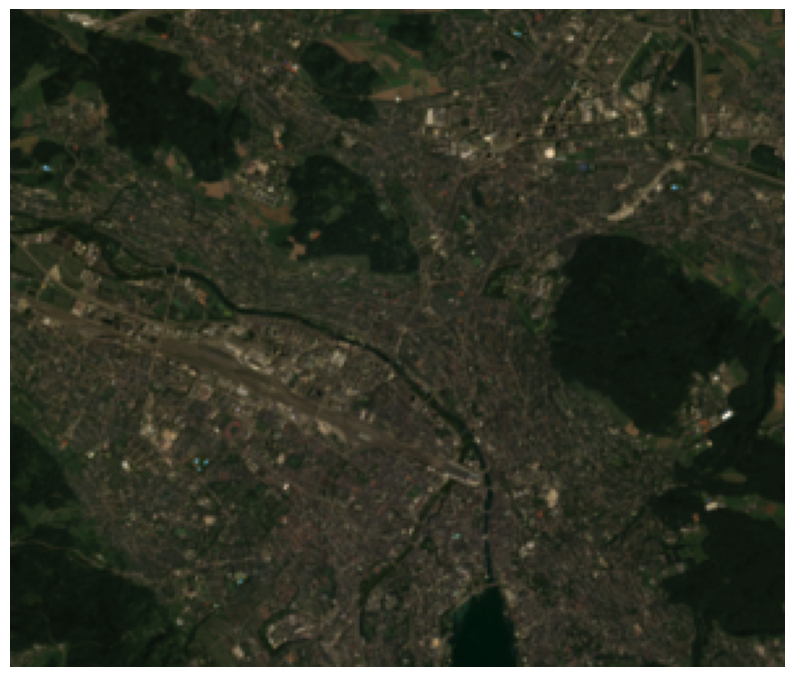

In [15]:
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt

ds = rxr.open_rasterio("../data/raw/Landsat/LandsatComposite_Zurich_2024.tif")

red   = ds.sel(band=3).values
green = ds.sel(band=2).values
blue  = ds.sel(band=1).values

rgb = np.stack([red, green, blue], axis=-1)

# Mask nodata (0)
rgb = np.where(rgb == 0, np.nan, rgb)

# Normalize
rgb_min = np.nanmin(rgb)
rgb_max = np.nanmax(rgb)
rgb_norm = (rgb - rgb_min) / (rgb_max - rgb_min)

plt.figure(figsize=(10,10))
plt.imshow(rgb_norm)
plt.axis("off")
plt.show()

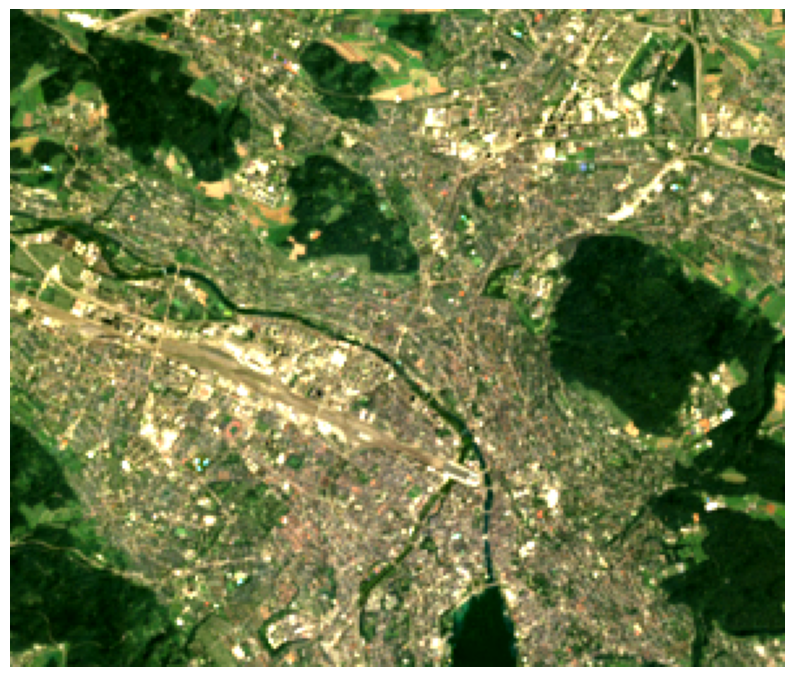

In [17]:
import numpy as np

def stretch_percentile(rgb, pmin=2, pmax=98):
    lo = np.nanpercentile(rgb, pmin)
    hi = np.nanpercentile(rgb, pmax)
    rgb_stretched = (rgb - lo) / (hi - lo)
    return np.clip(rgb_stretched, 0, 1)

rgb_stretched = stretch_percentile(rgb)

plt.figure(figsize=(10,10))
plt.imshow(rgb_stretched)
plt.axis("off")
plt.savefig("../outputs/RGB_24.png", dpi=300, bbox_inches="tight")
plt.show()